# Estimación de Edad a partir de Imágenes Faciales — Regresión con CNN

**Proyecto:** Workshop 2 — Deep Learning / Visión por Computador  
**Problema:** Regresión — predecir la edad numérica de una persona a partir de su imagen facial.  
**Dataset:** UTKFace (Kaggle) — dataset completo (`jangedoo/utkface-new`).  
**Framework:** TensorFlow / Keras  
**Autor:** [Nombre del estudiante]  
**Fecha:** [Fecha de entrega]

---

## 0. Configuración Global y Carga de Librerías

En esta sección se importan todas las librerías necesarias y se fijan las semillas aleatorias para garantizar la **reproducibilidad** del experimento. Fijar la semilla en NumPy, TensorFlow y Python asegura que las divisiones de datos, la inicialización de pesos y el data augmentation produzcan los mismos resultados en cada ejecución.

In [ ]:
# ============================================================
# 0. CONFIGURACIÓN GLOBAL
# ============================================================
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from PIL import Image
from glob import glob
from tqdm import tqdm
import kagglehub

# --- Reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# --- Configuración de GPU ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        DEVICE = '/GPU:0'
        print(f"GPU configurada con memory_growth: {[g.name for g in gpus]}")
    except RuntimeError as e:
        print(f"Error configurando GPU: {e}")
        DEVICE = '/CPU:0'
else:
    DEVICE = '/CPU:0'
    print("No se detectó GPU, usando CPU.")

# --- Configuración de visualización ---
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# --- Descarga del dataset desde Kaggle ---
_dataset_root = kagglehub.dataset_download("jangedoo/utkface-new")
print("Path to dataset files:", _dataset_root)

# --- Directorios ---
DATA_DIR = os.path.join(_dataset_root, 'UTKFace')
FIGURES_DIR = 'figures/'
MODELS_DIR = 'models/'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Hiperparámetros globales ---
IMG_SIZE = 128        # Tamaño de redimensionamiento (128x128 píxeles)
CHANNELS = 3          # RGB
BATCH_SIZE = 64
EPOCHS = 50           # Máximo; EarlyStopping puede detener antes
LEARNING_RATE = 1e-3

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")
print(f"DEVICE seleccionado: {DEVICE}")
print(f"Semilla fijada: {SEED}")
print(f"Directorio de datos: {DATA_DIR}")

---
## 1. Análisis Preliminar del Problema

### 1.1 Justificación: ¿Por qué es un problema de regresión?

La **variable objetivo** (target) de este proyecto es la **edad** de la persona que aparece en la imagen facial. La edad es una variable numérica de naturaleza continua (o, en la práctica, un entero positivo que representa años cumplidos). Esto la diferencia fundamentalmente de un problema de clasificación, donde se asignarían categorías discretas sin orden cuantitativo inherente.

Aunque la edad toma valores enteros, desde el punto de vista del modelado es más adecuado tratarla como **variable continua** por las siguientes razones:

1. **Orden y distancia significativos:** La diferencia entre predecir 25 y 30 años (error de 5 años) es cualitativamente distinta de la diferencia entre predecir 25 y 60 años (error de 35 años). En clasificación pura, ambos errores serían simplemente "predicciones incorrectas", sin reflejar la magnitud del fallo.

2. **Relación suave con la entrada:** Los rasgos faciales cambian de forma gradual con la edad (aparición progresiva de arrugas, cambio en la textura de la piel, variación de proporciones faciales). Un modelo de regresión puede capturar esta relación continua, mientras que un clasificador discreto perdería esta granularidad.

3. **Función de pérdida apropiada:** Al usar regresión podemos optimizar métricas como MAE o MSE, que penalizan proporcionalmente al error en años. Esto alinea la optimización con el objetivo real: minimizar la distancia entre la edad predicha y la edad verdadera.

4. **El dataset UTKFace contiene la edad numérica exacta** codificada en el nombre de cada archivo de imagen, lo que habilita directamente el enfoque de regresión y permite aprovechar toda la información disponible.

**Variable objetivo (target):** Edad numérica en años (entero ≥ 0).  
**Variables de entrada:** Píxeles de la imagen facial redimensionada a 128 × 128 × 3.

### 1.2 Características de entrada

Las imágenes del dataset **UTKFace** siguen la siguiente convención de nombres:

```
[edad]_[género]_[raza]_[timestamp].jpg.chip.jpg
```

Donde:
- **edad:** entero (0 a 116 en los datos crudos).
- **género:** 0 = masculino, 1 = femenino.
- **raza:** 0 = blanco, 1 = negro, 2 = asiático, 3 = indio, 4 = otros.
- **timestamp:** identificador único de la imagen.

Cada imagen es un archivo JPEG recortado en torno al rostro (`chip`), en formato RGB (3 canales). La **resolución original varía** ampliamente: se han observado imágenes desde aproximadamente 50×50 hasta más de 450×450 píxeles. Esta variabilidad obliga a un paso de redimensionamiento durante el preprocesamiento para alimentar la CNN con un tensor de dimensiones fijas.

Las principales fuentes de variabilidad en las imágenes son:
- **Iluminación:** desde imágenes bien iluminadas hasta escenas con sombras fuertes o contraluz.
- **Pose:** la mayoría son aproximadamente frontales, pero hay variación en ángulo.
- **Fondo:** no estandarizado; se encuentran fondos muy diversos.
- **Calidad:** algunas imágenes son nítidas y de alta resolución; otras presentan desenfoque, compresión JPEG visible o baja resolución.
- **Oclusiones:** gafas, accesorios, cabello parcialmente sobre el rostro.

Estas fuentes de variabilidad hacen del problema un reto real para la generalización del modelo.

### 1.3 Protocolo de adquisición y limitaciones

El dataset utilizado es **UTKFace** (`jangedoo/utkface-new`), alojado en Kaggle. Es un dataset ampliamente utilizado en investigación de estimación de edad, compilado a partir de diversas fuentes públicas en internet, con más de 23,000 imágenes faciales etiquetadas con edad, género y raza.

**Información verificable:**
- Las etiquetas de edad están codificadas en los nombres de archivo.
- Las imágenes fueron recortadas para mostrar primariamente el rostro.

**Información NO documentada explícitamente:**
- No se detalla el método exacto de etiquetado de edades. Es posible que las edades se hayan obtenido de metadatos asociados (perfiles públicos, bases de datos), pero no se puede confirmar si fueron verificadas manualmente.
- No se documenta si hubo revisión de calidad o filtrado de imágenes erróneas.
- No se conoce el proceso de detección y recorte facial empleado.

**Limitaciones que esto implica:**
- **Ruido en etiquetas:** Algunas edades podrían ser incorrectas o aproximadas, lo que introduce un techo al rendimiento del modelo.
- **Sesgo demográfico:** La distribución de razas y géneros puede no ser uniforme, lo que podría generar predicciones más precisas para ciertos grupos demográficos.
- **Sesgo de selección:** Las imágenes provienen de internet y no representan una muestra aleatoria de la población mundial.

Estas limitaciones deben tenerse en cuenta al interpretar las métricas del modelo y al generalizar sus conclusiones.

---
## 2. Análisis Exploratorio de Datos (EDA)

Esta sección examina la distribución de edades, la calidad visual de las imágenes y posibles sesgos del dataset. Cada visualización va acompañada de una interpretación orientada al impacto en el modelo de regresión.

In [2]:
# ============================================================
# 2.1  CARGA DEL DATASET Y EXTRACCIÓN DE METADATOS
# ============================================================
# Se recorren todos los archivos .jpg.chip.jpg en DATA_DIR y se extraen
# edad, género y raza desde el nombre del archivo.

file_paths = sorted(glob(os.path.join(DATA_DIR, '*.jpg.chip.jpg')))
print(f"Total de archivos encontrados: {len(file_paths)}")

# Función para parsear el nombre de archivo UTKFace
def parse_utk_filename(filepath):
    """
    Extrae edad, género y raza del nombre de archivo UTKFace.
    Formato: edad_genero_raza_timestamp.jpg.chip.jpg
    Retorna un diccionario o None si el formato es inválido.
    """
    filename = os.path.basename(filepath)
    parts = filename.split('_')
    try:
        age = int(parts[0])
        gender = int(parts[1])      # 0=male, 1=female
        race = int(parts[2])        # 0-4
        return {'filepath': filepath, 'age': age, 'gender': gender, 'race': race}
    except (IndexError, ValueError):
        return None

# Parsear todos los archivos
records = []
errores_parseo = 0
for fp in file_paths:
    parsed = parse_utk_filename(fp)
    if parsed is not None:
        records.append(parsed)
    else:
        errores_parseo += 1

df = pd.DataFrame(records)
print(f"Imágenes parseadas correctamente: {len(df)}")
print(f"Imágenes con formato de nombre inválido (descartadas): {errores_parseo}")
print(f"\nPrimeras filas del DataFrame:")
df.head(10)

Total de archivos encontrados: 23707
Imágenes parseadas correctamente: 23704
Imágenes con formato de nombre inválido (descartadas): 3

Primeras filas del DataFrame:


,filepath,age,gender,race
0,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,0,0
1,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,0,0
2,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,0
3,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,0
4,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,0
5,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,0
6,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,0
7,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,0
8,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,2
9,/Users/Hever_Andre_Alfonso_Jimenez/.cache/kagg...,100,1,2


In [3]:
# ============================================================
# 2.2  FILTRADO DE EDADES EXTREMAS
# ============================================================
# Algunas imágenes reportan edades > 100 (hasta 116), que son
# poco realistas o tienen muy pocas muestras. Se filtran para
# reducir ruido.

AGE_MIN = 0
AGE_MAX = 100

print(f"Distribución antes del filtrado:")
print(f"  Rango: {df['age'].min()} – {df['age'].max()}")
print(f"  Total: {len(df)}")

# Filtrar
df = df[(df['age'] >= AGE_MIN) & (df['age'] <= AGE_MAX)].reset_index(drop=True)

print(f"\nDistribución después del filtrado (edad ∈ [{AGE_MIN}, {AGE_MAX}]):")
print(f"  Rango: {df['age'].min()} – {df['age'].max()}")
print(f"  Total: {len(df)}")

Distribución antes del filtrado:
  Rango: 1 – 116
  Total: 23704

Distribución después del filtrado (edad ∈ [0, 100]):
  Rango: 1 – 100
  Total: 23683


In [4]:
# ============================================================
# 2.3  ESTADÍSTICOS DESCRIPTIVOS DEL TARGET
# ============================================================
stats = df['age'].describe()
print("Estadísticos descriptivos de la variable 'age':")
print(f"  Media:              {stats['mean']:.2f} años")
print(f"  Mediana:            {df['age'].median():.2f} años")
print(f"  Desviación estándar:{stats['std']:.2f} años")
print(f"  Mínimo:             {stats['min']:.0f} años")
print(f"  Máximo:             {stats['max']:.0f} años")
print(f"  Q1 (25%):           {stats['25%']:.0f} años")
print(f"  Q3 (75%):           {stats['75%']:.0f} años")
print(f"  Rango intercuartil: {stats['75%'] - stats['25%']:.0f} años")
print(f"  Total de muestras:  {len(df)}")

Estadísticos descriptivos de la variable 'age':
  Media:              33.23 años
  Mediana:            29.00 años
  Desviación estándar:19.76 años
  Mínimo:             1 años
  Máximo:             100 años
  Q1 (25%):           23 años
  Q3 (75%):           45 años
  Rango intercuartil: 22 años
  Total de muestras:  23683


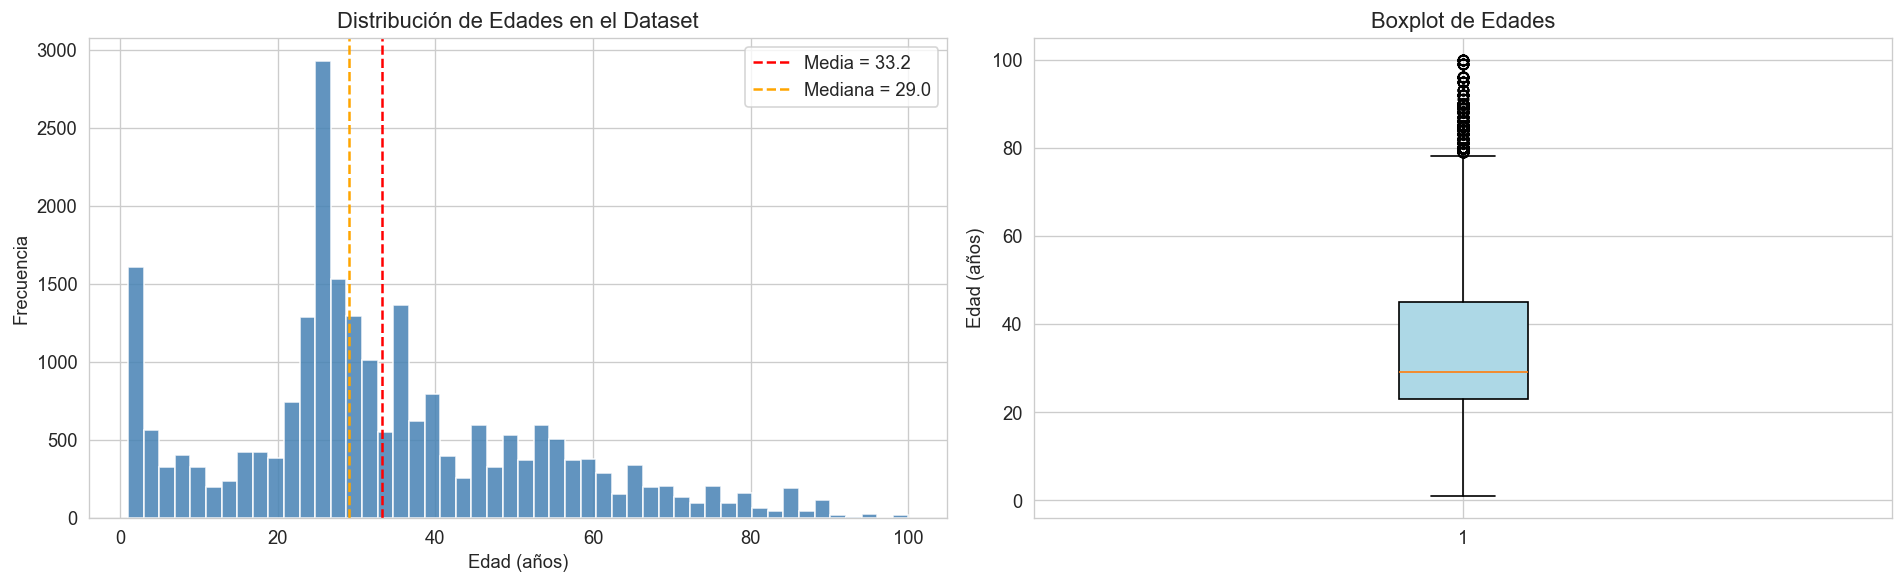

INTERPRETACIÓN:
La distribución de edades muestra una concentración marcada en el rango de 20-35 años,
lo que indica un desbalance significativo. Las edades extremas (< 5 y > 80 años)
tienen muy pocas muestras. Este desbalance puede llevar al modelo a predecir edades
cercanas al rango central con mayor frecuencia, subrepresentando los extremos.
Esto es esperable en datasets recopilados de internet, donde las fotografías
de adultos jóvenes son más abundantes.


In [5]:
# ============================================================
# 2.4  HISTOGRAMA DE EDADES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma general
axes[0].hist(df['age'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Media = {df['age'].mean():.1f}")
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Mediana = {df['age'].median():.1f}")
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Edades en el Dataset')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_ylabel('Edad (años)')
axes[1].set_title('Boxplot de Edades')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'histograma_edades.png'), bbox_inches='tight')
plt.show()

print("INTERPRETACIÓN:")
print("La distribución de edades muestra una concentración marcada en el rango de 20-35 años,")
print("lo que indica un desbalance significativo. Las edades extremas (< 5 y > 80 años)")
print("tienen muy pocas muestras. Este desbalance puede llevar al modelo a predecir edades")
print("cercanas al rango central con mayor frecuencia, subrepresentando los extremos.")
print("Esto es esperable en datasets recopilados de internet, donde las fotografías")
print("de adultos jóvenes son más abundantes.")

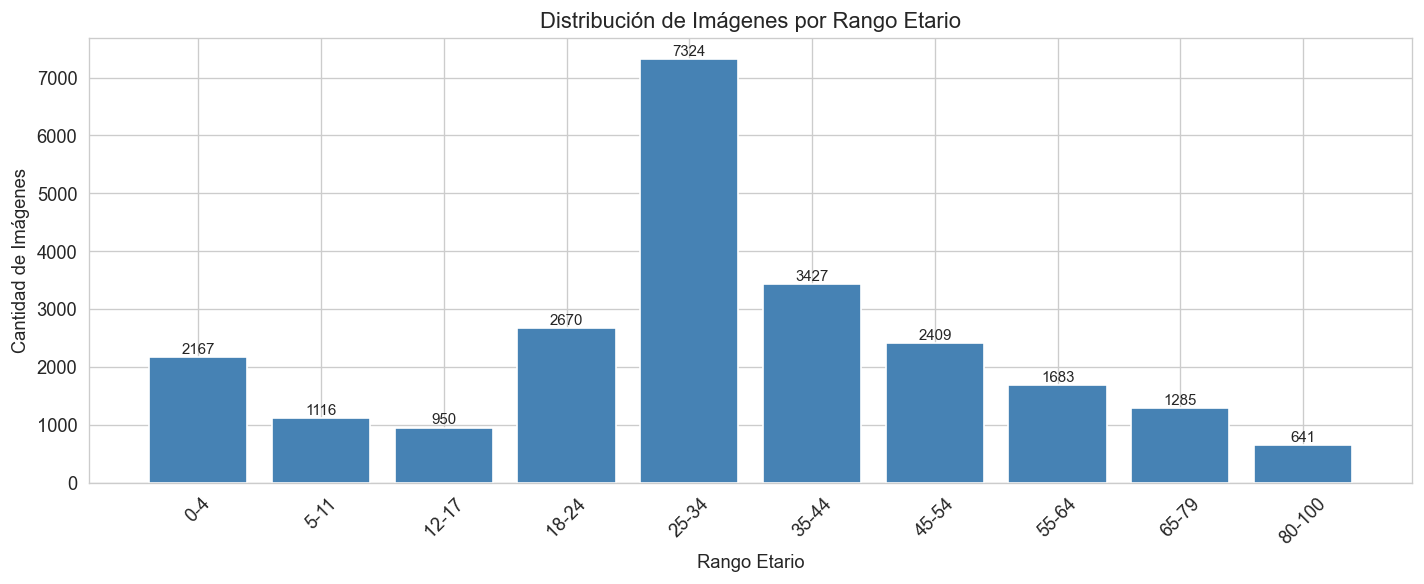


Distribución por rango etario:
age_group
0-4       2167
5-11      1116
12-17      950
18-24     2670
25-34     7324
35-44     3427
45-54     2409
55-64     1683
65-79     1285
80-100     641

INTERPRETACIÓN:
Se confirma el desbalance: los rangos 25-34 y 18-24 dominan el dataset.
Los rangos extremos (0-4, 80-100) son los menos representados.
Esto podría causar mayor error de predicción en edades infantiles y de adultos mayores.


In [6]:
# ============================================================
# 2.5  ANÁLISIS POR RANGOS ETARIOS
# ============================================================
# Agrupar edades en bins para exploración visual.
# Nota: el target del modelo sigue siendo numérico continuo.

bins = [0, 5, 12, 18, 25, 35, 45, 55, 65, 80, 100]
labels = ['0-4', '5-11', '12-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65-79', '80-100']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

group_counts = df['age_group'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(group_counts.index, group_counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Rango Etario')
ax.set_ylabel('Cantidad de Imágenes')
ax.set_title('Distribución de Imágenes por Rango Etario')
for bar, val in zip(bars, group_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nDistribución por rango etario:")
print(group_counts.to_string())
print("\nINTERPRETACIÓN:")
print("Se confirma el desbalance: los rangos 25-34 y 18-24 dominan el dataset.")
print("Los rangos extremos (0-4, 80-100) son los menos representados.")
print("Esto podría causar mayor error de predicción en edades infantiles y de adultos mayores.")

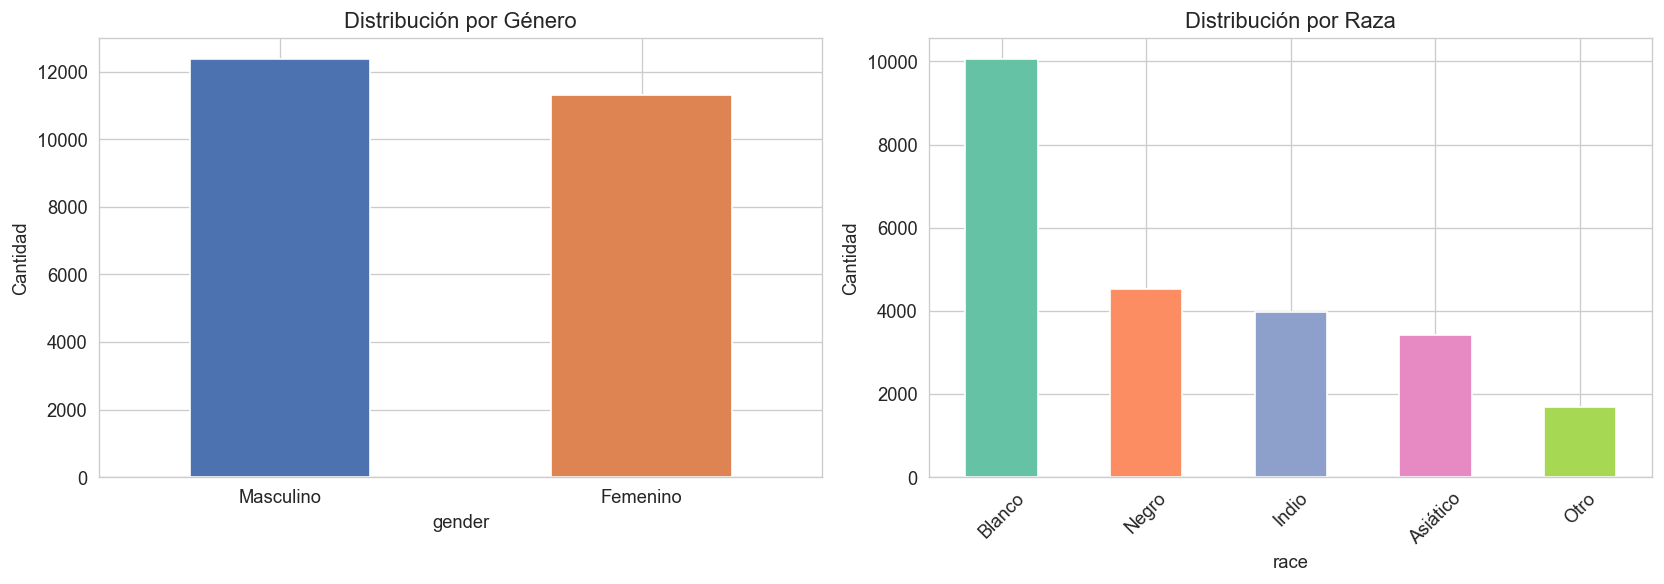

INTERPRETACIÓN:
Si existe un sesgo demográfico (p. ej., más imágenes de personas blancas o masculinas),
el modelo podría generalizar peor en grupos subrepresentados. Esto es una limitación
importante que debe reportarse y tenerse en cuenta al desplegar el modelo.


In [7]:
# ============================================================
# 2.6  DISTRIBUCIÓN POR GÉNERO Y RAZA
# ============================================================
gender_map = {0: 'Masculino', 1: 'Femenino'}
race_map = {0: 'Blanco', 1: 'Negro', 2: 'Asiático', 3: 'Indio', 4: 'Otro'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Género
df['gender'].map(gender_map).value_counts().plot.bar(ax=axes[0], color=['#4C72B0', '#DD8452'], edgecolor='white')
axes[0].set_title('Distribución por Género')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=0)

# Raza
df['race'].map(race_map).value_counts().plot.bar(ax=axes[1], color=sns.color_palette('Set2', 5), edgecolor='white')
axes[1].set_title('Distribución por Raza')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("INTERPRETACIÓN:")
print("Si existe un sesgo demográfico (p. ej., más imágenes de personas blancas o masculinas),")
print("el modelo podría generalizar peor en grupos subrepresentados. Esto es una limitación")
print("importante que debe reportarse y tenerse en cuenta al desplegar el modelo.")

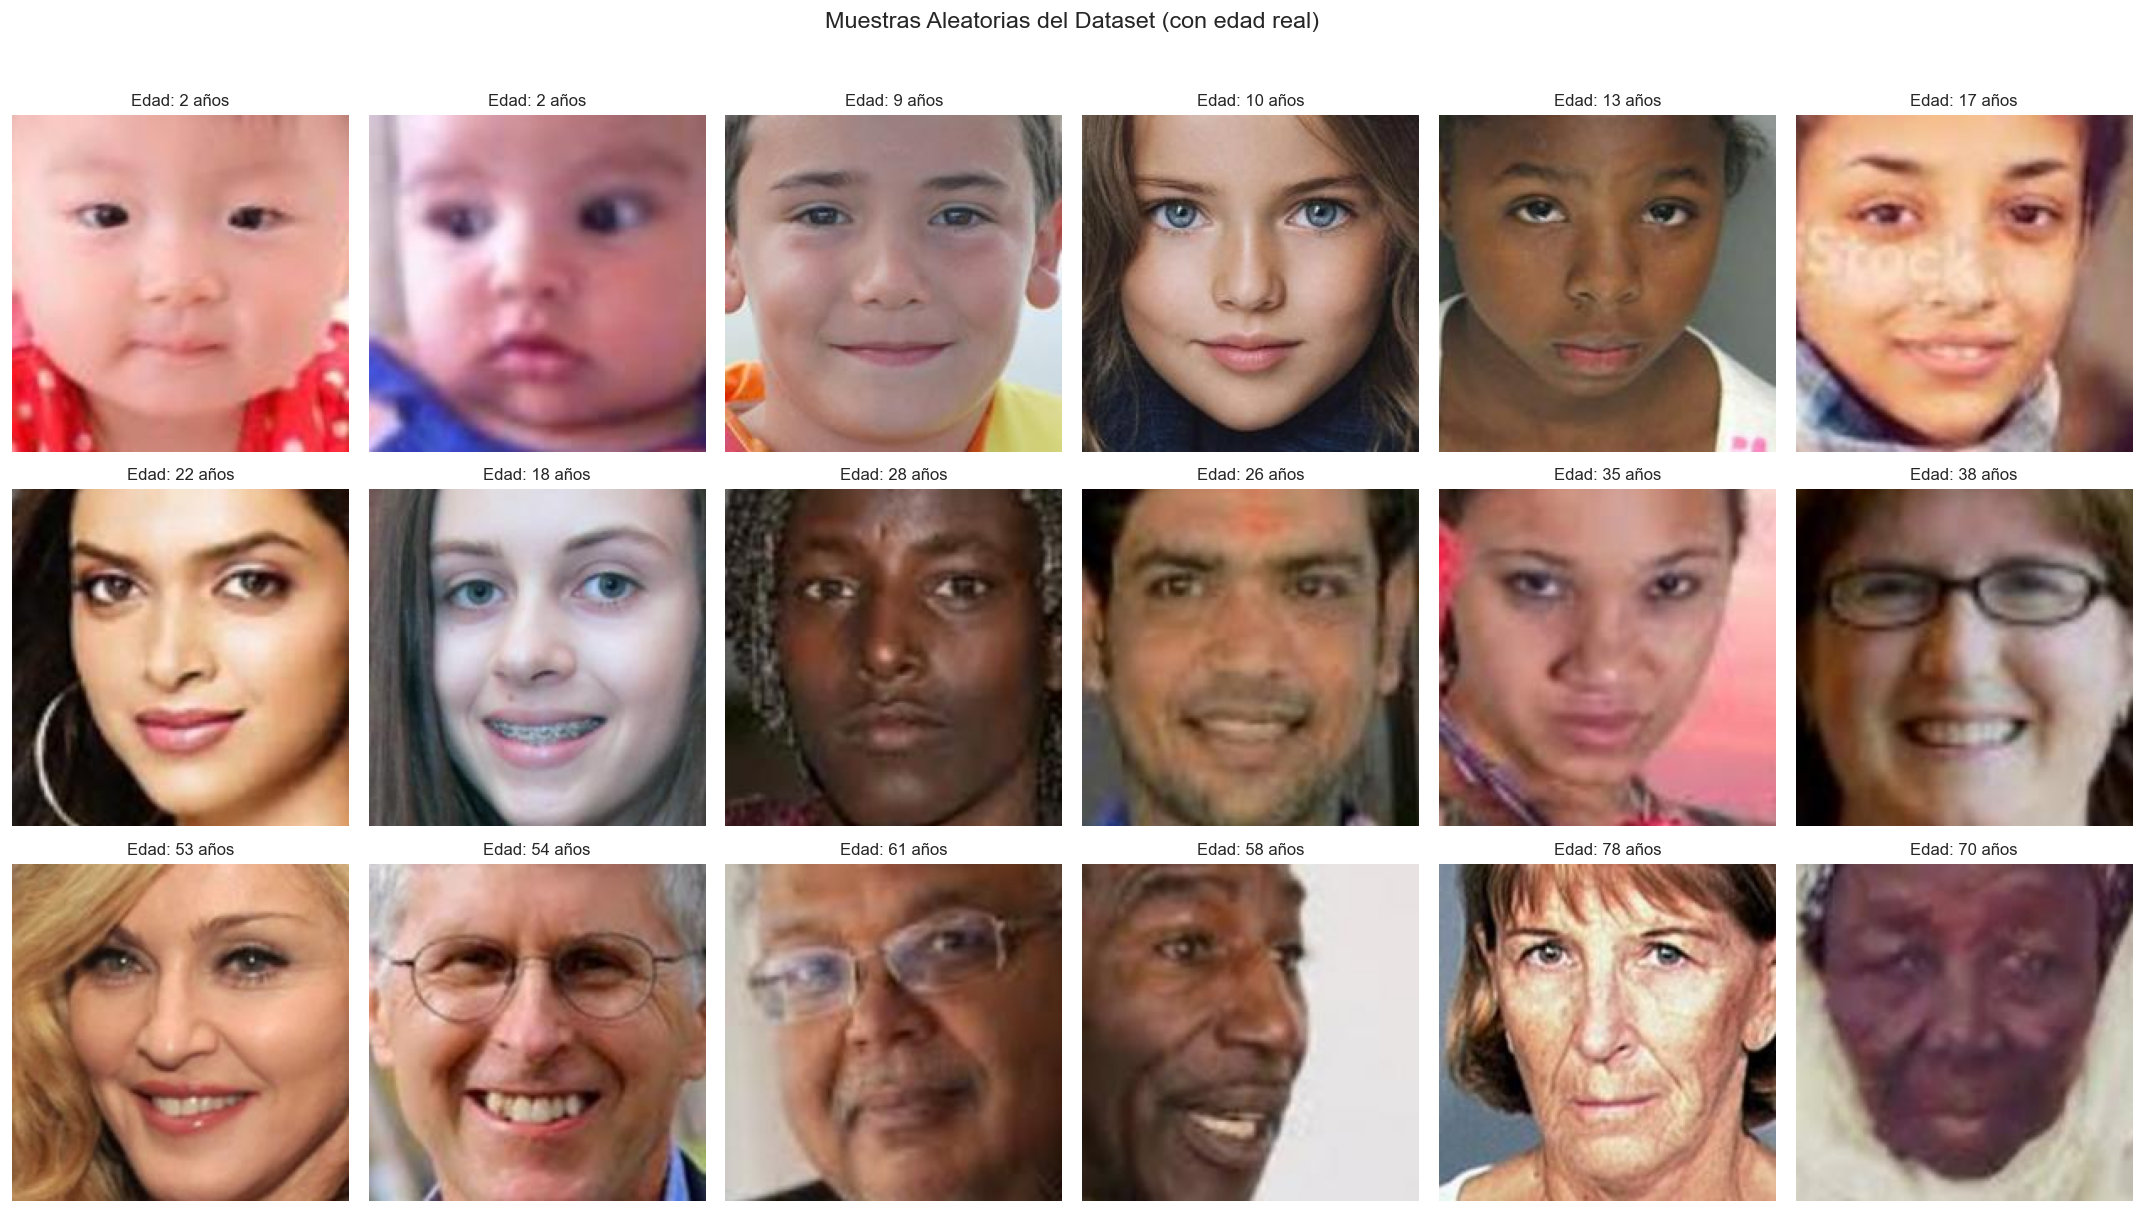

INTERPRETACIÓN:
Las muestras muestran la diversidad del dataset en términos de edad, iluminación,
pose, calidad y fondo. Esta variabilidad es positiva para la generalización,
pero también introduce ruido que el modelo debe aprender a manejar.


In [8]:
# ============================================================
# 2.7  VISUALIZACIÓN DE MUESTRAS REPRESENTATIVAS
# ============================================================
fig, axes = plt.subplots(3, 6, figsize=(18, 10))
fig.suptitle('Muestras Aleatorias del Dataset (con edad real)', fontsize=14, y=1.02)

# Seleccionar muestras de distintos rangos etarios
sample_indices = []
for group in df['age_group'].cat.categories:
    group_df = df[df['age_group'] == group]
    if len(group_df) > 0:
        n_samples = min(2, len(group_df))
        sample_indices.extend(group_df.sample(n_samples, random_state=SEED).index.tolist())

# Limitar a 18 muestras (3x6)
sample_indices = sample_indices[:18]

for idx, ax in enumerate(axes.flat):
    if idx < len(sample_indices):
        row = df.iloc[sample_indices[idx]]
        try:
            img = Image.open(row['filepath'])
            ax.imshow(img)
            ax.set_title(f"Edad: {row['age']} años", fontsize=10)
        except Exception as e:
            ax.text(0.5, 0.5, 'Error', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'muestras_dataset.png'), bbox_inches='tight')
plt.show()

print("INTERPRETACIÓN:")
print("Las muestras muestran la diversidad del dataset en términos de edad, iluminación,")
print("pose, calidad y fondo. Esta variabilidad es positiva para la generalización,")
print("pero también introduce ruido que el modelo debe aprender a manejar.")

Analizando propiedades de imagen (puede tomar unos minutos)...


Analizando: 100%|██████████| 2000/2000 [00:02<00:00, 798.03it/s]


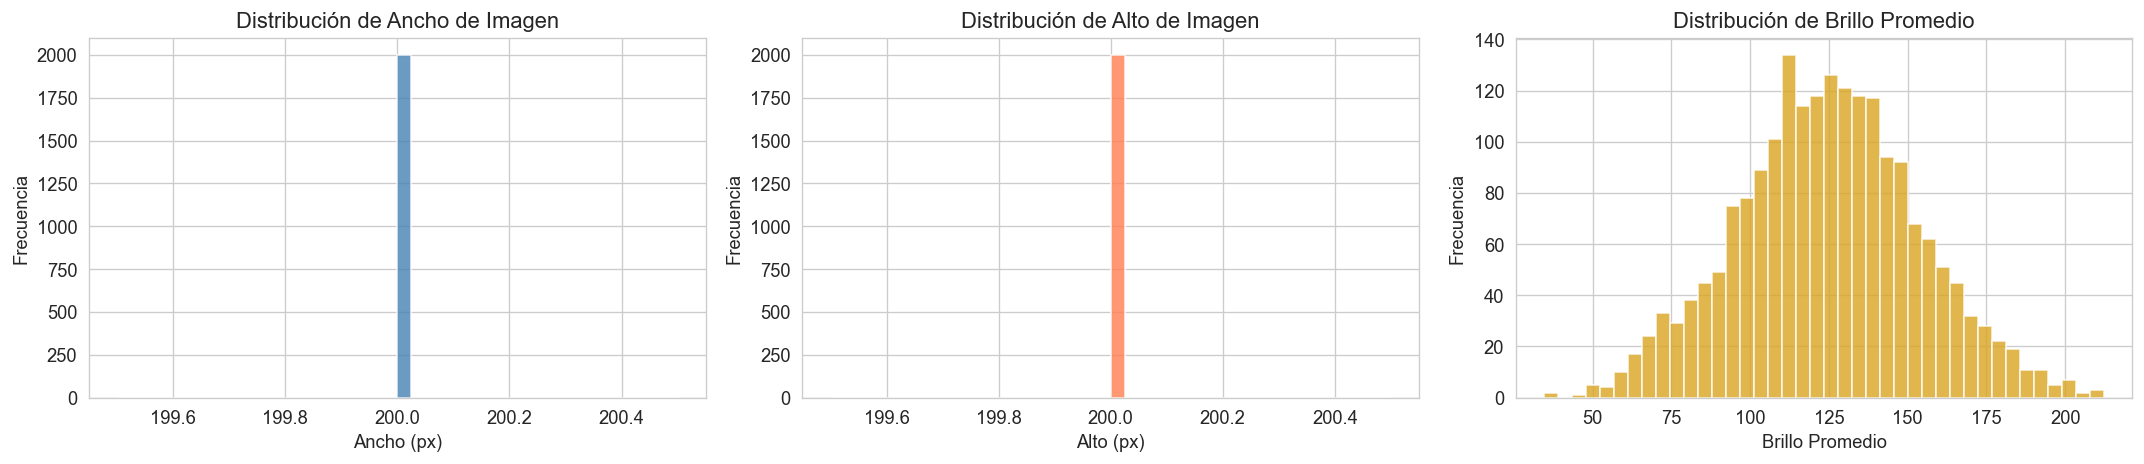


Estadísticos de resolución:
  Ancho  — min: 200px, max: 200px, media: 200px
  Alto   — min: 200px, max: 200px, media: 200px
  Brillo — min: 35, max: 212, media: 125

INTERPRETACIÓN:
La variabilidad de resoluciones obliga a redimensionar todas las imágenes a un tamaño fijo.
La distribución de brillo indica diversidad de condiciones de iluminación,
lo que justifica el uso de data augmentation con variaciones de brillo.


In [9]:
# ============================================================
# 2.8  ANÁLISIS DE CALIDAD Y VARIABILIDAD DE IMAGEN
# ============================================================
# Analizar resoluciones, brillo promedio, contraste
print("Analizando propiedades de imagen (puede tomar unos minutos)...")

sample_for_analysis = df.sample(min(2000, len(df)), random_state=SEED)
widths, heights, brightness_vals = [], [], []

for _, row in tqdm(sample_for_analysis.iterrows(), total=len(sample_for_analysis), desc="Analizando"):
    try:
        img = Image.open(row['filepath'])
        w, h = img.size
        widths.append(w)
        heights.append(h)
        # Brillo promedio (conversión a escala de grises)
        gray = np.array(img.convert('L'))
        brightness_vals.append(gray.mean())
    except:
        pass

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(widths, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Ancho (px)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Ancho de Imagen')

axes[1].hist(heights, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Alto (px)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Alto de Imagen')

axes[2].hist(brightness_vals, bins=40, color='goldenrod', edgecolor='white', alpha=0.8)
axes[2].set_xlabel('Brillo Promedio')
axes[2].set_ylabel('Frecuencia')
axes[2].set_title('Distribución de Brillo Promedio')

plt.tight_layout()
plt.show()

print(f"\nEstadísticos de resolución:")
print(f"  Ancho  — min: {min(widths)}px, max: {max(widths)}px, media: {np.mean(widths):.0f}px")
print(f"  Alto   — min: {min(heights)}px, max: {max(heights)}px, media: {np.mean(heights):.0f}px")
print(f"  Brillo — min: {min(brightness_vals):.0f}, max: {max(brightness_vals):.0f}, media: {np.mean(brightness_vals):.0f}")
print(f"\nINTERPRETACIÓN:")
print(f"La variabilidad de resoluciones obliga a redimensionar todas las imágenes a un tamaño fijo.")
print(f"La distribución de brillo indica diversidad de condiciones de iluminación,")
print(f"lo que justifica el uso de data augmentation con variaciones de brillo.")

---
## 3. Preprocesamiento de Datos

### Decisiones de diseño

1. **Redimensionamiento a 128×128:** Compromiso entre resolución suficiente para capturar rasgos faciales (arrugas, textura de piel) y eficiencia computacional. Tamaños menores (64×64) perderían detalle relevante para distinguir edades similares; tamaños mayores (224×224) aumentarían significativamente el tiempo de entrenamiento sin garantía de mejora proporcional.

2. **Normalización a [0, 1]:** Dividir los valores de píxel por 255.0 escala los datos al rango [0, 1], lo que facilita y estabiliza la convergencia del optimizador basado en gradiente. Esto evita que valores grandes (0-255) produzcan gradientes desproporcionados.

3. **Conservación de RGB (3 canales):** La información de color puede ser relevante para la estimación de edad (tono de piel, encanecimiento del cabello, enrojecimiento), por lo que se conservan los 3 canales.

4. **División train/val/test:** Se utiliza una proporción **70% / 15% / 15%**, que es estándar para datasets de tamaño mediano. El conjunto de validación se usa para monitorear el sobreajuste y ajustar hiperparámetros; el de test se reserva exclusivamente para la evaluación final.

5. **Data Augmentation:** Se aplican transformaciones suaves (rotación ≤ 15°, flip horizontal, leves cambios de brillo y zoom) **solo al conjunto de entrenamiento**. Estas transformaciones simulan variaciones reales (una cara ligeramente girada sigue teniendo la misma edad) y ayudan al modelo a generalizar. Se evitan transformaciones agresivas como flips verticales (una cara al revés no es natural) o distorsiones geométricas fuertes que podrían alterar los rasgos faciales relevantes para la edad.

In [10]:
# ============================================================
# 3.1  CARGA DE IMÁGENES Y PREPARACIÓN DE ARRAYS
# ============================================================
print(f"Cargando y redimensionando {len(df)} imágenes a {IMG_SIZE}x{IMG_SIZE}...")

images = []
ages = []
indices_validos = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Cargando imágenes"):
    try:
        img = Image.open(row['filepath']).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
        img_array = np.array(img, dtype=np.float32) / 255.0  # Normalización [0, 1]
        images.append(img_array)
        ages.append(row['age'])
        indices_validos.append(idx)
    except Exception as e:
        pass  # Descartar imágenes corruptas silenciosamente

X = np.array(images)
y = np.array(ages, dtype=np.float32)

print(f"\nImágenes cargadas exitosamente: {len(X)}")
print(f"Forma del tensor de imágenes: {X.shape}  → (N, alto, ancho, canales)")
print(f"Forma del vector de edades:   {y.shape}")
print(f"Rango de píxeles: [{X.min():.2f}, {X.max():.2f}]")
print(f"Rango de edades:  [{y.min():.0f}, {y.max():.0f}]")
print(f"Tipo de datos — X: {X.dtype}, y: {y.dtype}")

Cargando y redimensionando 23683 imágenes a 128x128...


Cargando imágenes: 100%|██████████| 23683/23683 [00:47<00:00, 494.80it/s]



Imágenes cargadas exitosamente: 23683
Forma del tensor de imágenes: (23683, 128, 128, 3)  → (N, alto, ancho, canales)
Forma del vector de edades:   (23683,)
Rango de píxeles: [0.00, 1.00]
Rango de edades:  [1, 100]
Tipo de datos — X: float32, y: float32


División de datos completada:
  X_train: (16577, 128, 128, 3)  — 16577 muestras (70.0%)
  X_val:   (3553, 128, 128, 3)  — 3553 muestras (15.0%)
  X_test:  (3553, 128, 128, 3)  — 3553 muestras (15.0%)

Media de edad por conjunto:
  Train: 33.23 ± 19.77
  Val:   33.23 ± 19.73
  Test:  33.23 ± 19.76


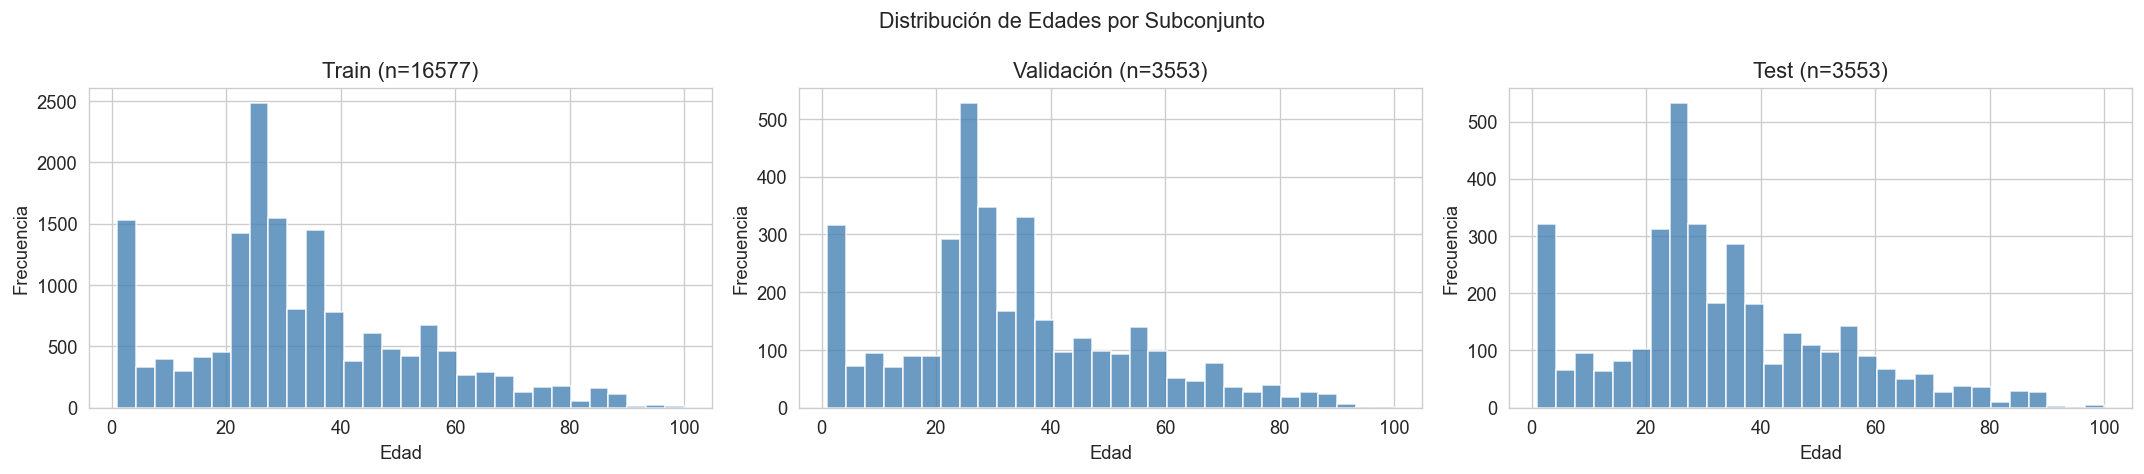


La estratificación por bins de edad garantiza que cada subconjunto
tiene una distribución de edades similar, evitando que el modelo se
evalúe en un rango de edades no visto durante el entrenamiento.


In [11]:
# ============================================================
# 3.2  DIVISIÓN EN TRAIN / VALIDACIÓN / TEST
# ============================================================
# Proporción: 70% train / 15% val / 15% test
# Se usa estratificación por bins de edad para mantener
# distribuciones similares en cada subconjunto.

# Crear bins de edad para estratificación
y_bins = pd.cut(y, bins=10, labels=False)

# Primera división: separar test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y_bins
)

# Recalcular bins para la segunda división
y_temp_bins = pd.cut(y_temp, bins=10, labels=False)

# Segunda división: separar val (15% del total ≈ 17.6% del restante)
val_ratio = 0.15 / 0.85  # ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=SEED, stratify=y_temp_bins
)

print("División de datos completada:")
print(f"  X_train: {X_train.shape}  — {len(X_train)} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f"  X_val:   {X_val.shape}  — {len(X_val)} muestras ({len(X_val)/len(X)*100:.1f}%)")
print(f"  X_test:  {X_test.shape}  — {len(X_test)} muestras ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nMedia de edad por conjunto:")
print(f"  Train: {y_train.mean():.2f} ± {y_train.std():.2f}")
print(f"  Val:   {y_val.mean():.2f} ± {y_val.std():.2f}")
print(f"  Test:  {y_test.mean():.2f} ± {y_test.std():.2f}")

# Verificar que las distribuciones son similares
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, data, name in zip(axes, [y_train, y_val, y_test], ['Train', 'Validación', 'Test']):
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{name} (n={len(data)})')
    ax.set_xlabel('Edad')
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribución de Edades por Subconjunto', fontsize=13)
plt.tight_layout()
plt.show()

print("\nLa estratificación por bins de edad garantiza que cada subconjunto")
print("tiene una distribución de edades similar, evitando que el modelo se")
print("evalúe en un rango de edades no visto durante el entrenamiento.")

In [12]:
# ============================================================
# 3.3  DATA AUGMENTATION (solo para entrenamiento)
# ============================================================
# Se usa ImageDataGenerator de Keras para aplicar transformaciones
# en tiempo real durante el entrenamiento. Esto NO modifica los datos
# almacenados; las transformaciones se aplican on-the-fly en cada batch.

train_datagen = ImageDataGenerator(
    rotation_range=15,          # Rotación aleatoria de hasta ±15°
    width_shift_range=0.1,      # Traslación horizontal de hasta 10%
    height_shift_range=0.1,     # Traslación vertical de hasta 10%
    horizontal_flip=True,       # Flip horizontal (una cara reflejada tiene la misma edad)
    brightness_range=[0.8, 1.2],# Variación de brillo ±20%
    zoom_range=0.1,             # Zoom aleatorio de hasta 10%
    fill_mode='nearest'         # Rellenar píxeles vacíos con el vecino más cercano
)

# Para validación y test NO se aplica augmentation, solo normalización
# (que ya se hizo al cargar las imágenes).
val_datagen = ImageDataGenerator()  # Sin transformaciones

# Crear generadores
train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)
val_generator = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)

print("Data Augmentation configurado:")
print("  - Rotación: ±15°")
print("  - Traslación: ±10% horizontal y vertical")
print("  - Flip horizontal: Sí")
print("  - Variación de brillo: [0.8, 1.2]")
print("  - Zoom: ±10%")
print("  - Flip vertical: NO (caras al revés no son naturales)")
print("  - Distorsión geométrica agresiva: NO (podría alterar rasgos faciales)")
print(f"\nBatches por época (train): {len(train_generator)}")
print(f"Batches por época (val):   {len(val_generator)}")

Data Augmentation configurado:
  - Rotación: ±15°
  - Traslación: ±10% horizontal y vertical
  - Flip horizontal: Sí
  - Variación de brillo: [0.8, 1.2]
  - Zoom: ±10%
  - Flip vertical: NO (caras al revés no son naturales)
  - Distorsión geométrica agresiva: NO (podría alterar rasgos faciales)

Batches por época (train): 260
Batches por época (val):   56


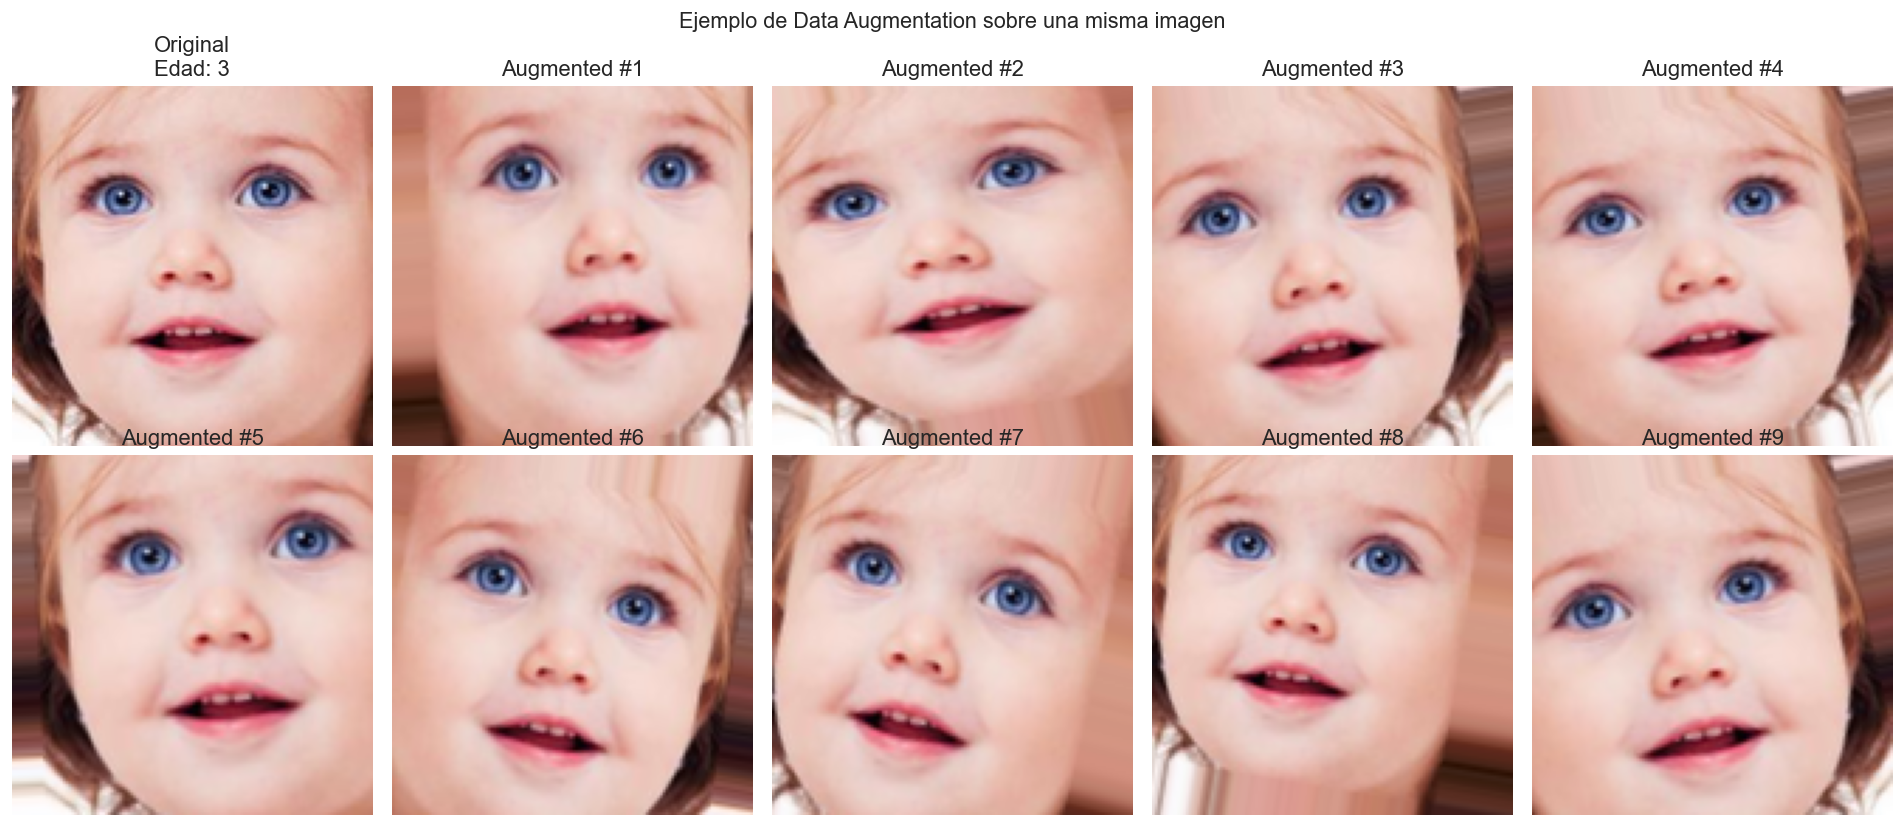

Las transformaciones son suaves y mantienen la información facial relevante.
La edad de la persona no cambia con estas transformaciones, lo que las hace seguras.


In [13]:
# ============================================================
# 3.4  VISUALIZACIÓN DE AUGMENTATION
# ============================================================
# Mostrar cómo se ven las transformaciones aplicadas a una imagen.
# Se usa un generador sin brightness_range para evitar la conversión
# interna a PIL uint8 que corrompe imágenes float normalizadas [0,1].
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Ejemplo de Data Augmentation sobre una misma imagen', fontsize=13)

sample_img = X_train[0:1]  # Una imagen, shape (1, 128, 128, 3)
viz_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)
temp_gen = viz_datagen.flow(sample_img, batch_size=1, seed=None)

axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title(f'Original\nEdad: {y_train[0]:.0f}')
axes[0, 0].axis('off')

for i in range(1, 10):
    row, col = divmod(i, 5)
    aug_img = next(temp_gen)[0]
    axes[row, col].imshow(np.clip(aug_img, 0, 1))
    axes[row, col].set_title(f'Augmented #{i}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Las transformaciones son suaves y mantienen la información facial relevante.")
print("La edad de la persona no cambia con estas transformaciones, lo que las hace seguras.")

---
## 4. Diseño y Entrenamiento del Modelo CNN para Regresión

### Decisiones de arquitectura

Se diseña una CNN desde cero con las siguientes decisiones:

1. **Bloques convolucionales progresivos:** Se incrementan los filtros (32 → 64 → 128 → 256) para capturar características de complejidad creciente: bordes y texturas simples en capas tempranas, patrones complejos (arrugas, forma de mandíbula) en capas profundas.

2. **Batch Normalization después de cada convolución:** Normaliza las activaciones intermedias, lo que estabiliza y acelera el entrenamiento. Esto permite usar learning rates más altos y reduce la sensibilidad a la inicialización de pesos.

3. **MaxPooling (2×2) después de cada bloque:** Reduce la dimensionalidad espacial progresivamente, lo que disminuye el costo computacional y añade un grado de invariancia a pequeñas traslaciones.

4. **Dropout (0.25 en bloques convolucionales, 0.5 en capas densas):** Técnica de regularización que desactiva neuronas aleatoriamente durante el entrenamiento, obligando al modelo a no depender de características individuales y reduciendo el sobreajuste.

5. **Capas densas finales (512 → 1):** Integran la información espacial extraída por la parte convolucional. La capa de salida tiene **una sola neurona sin activación** (activación lineal), lo que permite predecir cualquier valor numérico real, adecuado para regresión.

6. **Función de pérdida:** Se utiliza **Huber Loss** (con delta=1.0), que combina las ventajas de MSE y MAE: es cuadrática para errores pequeños (sensible a errores leves) y lineal para errores grandes (robusta a outliers). Esto es apropiado dado que el dataset puede contener edades etiquetadas con ruido.

7. **Optimizador Adam** con learning rate inicial de 0.001: Adam combina las ventajas de RMSProp y momentum, adaptando la tasa de aprendizaje por parámetro. Es el optimizador estándar para CNNs por su estabilidad y velocidad de convergencia.

8. **Callbacks:**
   - **EarlyStopping:** Detiene el entrenamiento si la pérdida de validación no mejora en 10 épocas, evitando sobreajuste.
   - **ReduceLROnPlateau:** Reduce el learning rate por un factor de 0.5 si la pérdida de validación se estanca por 5 épocas, permitiendo un ajuste fino.
   - **ModelCheckpoint:** Guarda el mejor modelo (según pérdida de validación) para usarlo en la evaluación final.

In [ ]:
# ============================================================
# 4.1  DEFINICIÓN DE LA ARQUITECTURA CNN
# ============================================================

def build_age_regression_cnn(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS)):
    """
    Construye una CNN para regresión de edad.
    
    Arquitectura:
    - 4 bloques convolucionales con BatchNorm, ReLU, MaxPool y Dropout
    - GlobalAveragePooling para reducir a vector
    - Capas densas finales con Dropout
    - Salida: 1 neurona, activación lineal (regresión)
    """
    model = keras.Sequential(name='CNN_Age_Regression')
    
    # --- Bloque 1: 32 filtros ---
    model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))
    
    # --- Bloque 2: 64 filtros ---
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))
    
    # --- Bloque 3: 128 filtros ---
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))
    
    # --- Bloque 4: 256 filtros ---
    model.add(layers.Conv2D(256, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(layers.Dropout(0.25))
    
    # --- Global Average Pooling ---
    model.add(layers.GlobalAveragePooling2D())
    
    # --- Capas Densas ---
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))
    
    model.add(layers.Dense(128))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))
    
    # --- Capa de Salida ---
    model.add(layers.Dense(1, activation='linear'))
    
    return model

# Construir el modelo en el dispositivo configurado (GPU o CPU)
with tf.device(DEVICE):
    model = build_age_regression_cnn()
model.summary()
print(f"\nModelo construido en: {DEVICE}")

In [15]:
# ============================================================
# 4.2  COMPILACIÓN DEL MODELO
# ============================================================
# Función de pérdida: Huber Loss
# - Para errores pequeños (< delta): se comporta como MSE (cuadrática)
# - Para errores grandes (> delta): se comporta como MAE (lineal)
# - Esto la hace robusta a outliers en las etiquetas de edad.

model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=keras.losses.Huber(delta=1.0),  # Huber Loss
    metrics=['mae']                       # MAE como métrica de monitoreo
)

print("Modelo compilado:")
print(f"  Función de pérdida: Huber Loss (delta=1.0)")
print(f"  Optimizador:        Adam (lr={LEARNING_RATE})")
print(f"  Métrica:            MAE (Mean Absolute Error)")
print(f"  Total parámetros:   {model.count_params():,}")

Modelo compilado:
  Función de pérdida: Huber Loss (delta=1.0)
  Optimizador:        Adam (lr=0.001)
  Métrica:            MAE (Mean Absolute Error)
  Total parámetros:   1,376,033


In [16]:
# ============================================================
# 4.3  CONFIGURACIÓN DE CALLBACKS
# ============================================================
model_path = os.path.join(MODELS_DIR, 'mejor_modelo_edad.h5')

callbacks_list = [
    # Detener entrenamiento si val_loss no mejora en 10 épocas
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Reducir learning rate si val_loss se estanca por 5 épocas
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,          # Nuevo lr = lr * 0.5
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    # Guardar el mejor modelo según val_loss
    callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configurados:")
print("  1. EarlyStopping  — patience=10, monitor=val_loss")
print("  2. ReduceLROnPlateau — factor=0.5, patience=5, min_lr=1e-6")
print(f"  3. ModelCheckpoint — guardando en: {model_path}")

Callbacks configurados:
  1. EarlyStopping  — patience=10, monitor=val_loss
  2. ReduceLROnPlateau — factor=0.5, patience=5, min_lr=1e-6
  3. ModelCheckpoint — guardando en: models/mejor_modelo_edad.h5


In [17]:
# ============================================================
# 4.4  ENTRENAMIENTO DEL MODELO
# ============================================================
print(f"Iniciando entrenamiento...")
print(f"  Épocas máximas: {EPOCHS}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Train samples:  {len(X_train)}")
print(f"  Val samples:    {len(X_val)}")
print()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks_list,
    verbose=1
)

print(f"\nEntrenamiento finalizado en {len(history.history['loss'])} épocas.")
print(f"Mejor val_loss: {min(history.history['val_loss']):.4f}")
print(f"Mejor val_mae:  {min(history.history['val_mae']):.4f}")

Iniciando entrenamiento...
  Épocas máximas: 50
  Batch size:     64
  Train samples:  16577
  Val samples:    3553

Epoch 1/50
 30/260 ━━━━━━━━━━━━━━━━━━━━ 14:04 4s/step - loss: 32.2863 - mae: 32.7830

KeyboardInterrupt: 

---
## 5. Evaluación del Modelo

La evaluación se realiza sobre los tres conjuntos (train, val, test) para diagnosticar el comportamiento del modelo:
- Si train es mucho mejor que val/test → **sobreajuste** (overfitting).
- Si todos son malos → **subajuste** (underfitting).
- Si todos son similares y aceptables → **buen ajuste**.

Se reportan tres métricas complementarias:
- **MAE:** Error promedio en años; la más interpretable.
- **RMSE:** Penaliza más los errores grandes; útil para detectar predicciones muy desviadas.
- **R²:** Indica qué proporción de la variabilidad de la edad es explicada por el modelo (1.0 = perfecto).

In [ ]:
# ============================================================
# 5.1  CURVAS DE ENTRENAMIENTO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Curva de pérdida (Huber Loss)
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Curvas de Pérdida (Huber Loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de MAE
axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('MAE (años)')
axes[1].set_title('Curvas de MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curvas_entrenamiento.png'), bbox_inches='tight')
plt.show()

print("INTERPRETACIÓN:")
print("- Si las curvas de train y val convergen juntas → buen ajuste.")
print("- Si train sigue bajando pero val se estanca o sube → sobreajuste.")
print("- Si ambas se estancan en valores altos → subajuste (modelo muy simple).")
print("- La reducción del learning rate se observa como cambios de pendiente en las curvas.")

In [ ]:
# ============================================================
# 5.2  CÁLCULO DE MÉTRICAS EN LOS 3 CONJUNTOS
# ============================================================

def evaluate_model(model, X, y_true, set_name):
    """Calcula MAE, RMSE y R² para un conjunto dado."""
    y_pred = model.predict(X, verbose=0).flatten()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"  {set_name:12s} — MAE: {mae:.2f} años | RMSE: {rmse:.2f} años | R²: {r2:.4f}")
    return y_pred, mae, rmse, r2

print("="*70)
print("MÉTRICAS DE EVALUACIÓN")
print("="*70)

y_pred_train, mae_train, rmse_train, r2_train = evaluate_model(model, X_train, y_train, "Train")
y_pred_val, mae_val, rmse_val, r2_val = evaluate_model(model, X_val, y_val, "Validación")
y_pred_test, mae_test, rmse_test, r2_test = evaluate_model(model, X_test, y_test, "Test")

print("="*70)

# Tabla resumen
results_df = pd.DataFrame({
    'Conjunto': ['Train', 'Validación', 'Test'],
    'MAE (años)': [mae_train, mae_val, mae_test],
    'RMSE (años)': [rmse_train, rmse_val, rmse_test],
    'R²': [r2_train, r2_val, r2_test]
})
print("\nTabla resumen:")
print(results_df.to_string(index=False))

In [ ]:
# ============================================================
# 5.3  INTERPRETACIÓN DE MÉTRICAS
# ============================================================
print("="*70)
print("INTERPRETACIÓN DETALLADA")
print("="*70)

# Diagnóstico de sobreajuste
gap_mae = mae_test - mae_train
print(f"\n1. DIAGNÓSTICO DE AJUSTE:")
print(f"   Diferencia MAE (test - train) = {gap_mae:.2f} años")
if gap_mae > 3:
    print(f"   → Hay indicios de SOBREAJUSTE: el modelo funciona notablemente mejor")
    print(f"     en los datos de entrenamiento que en los de prueba.")
elif gap_mae < 0.5:
    print(f"   → Buen ajuste: rendimiento similar entre train y test.")
else:
    print(f"   → Sobreajuste moderado: diferencia presente pero aceptable.")

print(f"\n2. MAE (Error Absoluto Medio):")
print(f"   El modelo se equivoca en promedio {mae_test:.1f} años en datos no vistos.")
print(f"   Esto significa que si la edad real es 30, la predicción típica estaría")
print(f"   entre {30 - mae_test:.0f} y {30 + mae_test:.0f} años.")

print(f"\n3. RMSE:")
print(f"   RMSE ({rmse_test:.1f}) > MAE ({mae_test:.1f}), lo que indica que hay")
print(f"   algunos errores grandes que inflan el RMSE. Estos probablemente")
print(f"   corresponden a edades extremas (niños o ancianos) donde el modelo")
print(f"   tiene menos ejemplos de entrenamiento.")

print(f"\n4. R² (Coeficiente de Determinación):")
print(f"   R² = {r2_test:.4f} en test.")
if r2_test > 0.7:
    print(f"   → El modelo explica más del {r2_test*100:.0f}% de la variabilidad de la edad.")
elif r2_test > 0.5:
    print(f"   → El modelo explica una porción moderada de la variabilidad.")
else:
    print(f"   → El modelo tiene dificultades para explicar la variabilidad de la edad.")

In [ ]:
# ============================================================
# 5.4  GRÁFICO DE VALORES REALES VS. PREDICHOS (TEST)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred_test, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Edad Real (años)')
axes[0].set_ylabel('Edad Predicha (años)')
axes[0].set_title('Edad Real vs. Edad Predicha (Test)')
axes[0].legend()
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

# Histograma de errores
errores = y_pred_test - y_test
axes[1].hist(errores, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(errores.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Error medio = {errores.mean():.2f}')
axes[1].set_xlabel('Error (predicha - real) en años')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Errores de Predicción (Test)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'real_vs_predicho.png'), bbox_inches='tight')
plt.show()

print("INTERPRETACIÓN:")
print("- En el gráfico de dispersión, los puntos cercanos a la línea roja indican")
print("  predicciones precisas. La dispersión aumenta en edades extremas.")
print(f"- El error medio es {errores.mean():.2f} años (sesgo de la predicción).")
print(f"- El error estándar es {errores.std():.2f} años.")
print(f"- {np.mean(np.abs(errores) <= 5)*100:.1f}% de las predicciones tienen error ≤ 5 años.")
print(f"- {np.mean(np.abs(errores) <= 10)*100:.1f}% de las predicciones tienen error ≤ 10 años.")

In [ ]:
# ============================================================
# 5.5  PREDICCIONES INDIVIDUALES COMENTADAS
# ============================================================
# Mostrar algunas predicciones buenas y malas para analizar cualitativamente.
np.random.seed(SEED)
test_indices = np.random.choice(len(X_test), size=12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Predicciones Individuales sobre el Conjunto de Test', fontsize=14)

for i, ax in enumerate(axes.flat):
    idx = test_indices[i]
    ax.imshow(X_test[idx])
    real = y_test[idx]
    pred = y_pred_test[idx]
    error = abs(pred - real)
    color = 'green' if error <= 5 else ('orange' if error <= 10 else 'red')
    ax.set_title(f'Real: {real:.0f} | Pred: {pred:.0f}\nError: {error:.1f}', 
                 fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Código de colores:")
print("  Verde:   error ≤ 5 años (buena predicción)")
print("  Naranja: error entre 5 y 10 años (aceptable)")
print("  Rojo:    error > 10 años (mala predicción)")

---
## 6. Prueba con Muestra Artificial

En esta sección se toma una imagen externa (no parte del dataset de entrenamiento) y se pasa por el modelo entrenado para evaluar cualitativamente su capacidad de inferencia. Se analiza el resultado y se discute la sensibilidad del modelo a perturbaciones.

In [ ]:
# ============================================================
# 6.1  CARGAR Y PREPROCESAR UNA IMAGEN EXTERNA
# ============================================================
# Opción 1: Usar una imagen del propio dataset de test
# Opción 2: Cargar una imagen externa (ajustar la ruta)

# Aquí usamos una imagen de test como demostración.
# Para una imagen externa: img_path = 'ruta/a/imagen_prueba.jpg'

# --- Demostración con imagen del test set ---
test_idx = 0
img_prueba = X_test[test_idx]
edad_real = y_test[test_idx]

# --- Para imagen externa, descomentar y ajustar: ---
# img_path = 'ruta/a/tu_imagen.jpg'
# img_prueba_pil = Image.open(img_path).convert('RGB')
# img_prueba_pil = img_prueba_pil.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
# img_prueba = np.array(img_prueba_pil, dtype=np.float32) / 255.0
# edad_real = None  # No conocemos la edad real

# Preprocesar para el modelo (agregar dimensión de batch)
img_input = np.expand_dims(img_prueba, axis=0)  # Shape: (1, 128, 128, 3)

# Predicción
edad_predicha = model.predict(img_input, verbose=0)[0, 0]

# Visualizar
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img_prueba)
titulo = f'Edad predicha: {edad_predicha:.1f} años'
if edad_real is not None:
    titulo += f'\nEdad real: {edad_real:.0f} años'
    titulo += f'\nError: {abs(edad_predicha - edad_real):.1f} años'
ax.set_title(titulo, fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'prueba_artificial.png'), bbox_inches='tight')
plt.show()

print(f"Edad predicha por el modelo: {edad_predicha:.1f} años")
if edad_real is not None:
    print(f"Edad real (etiqueta):        {edad_real:.0f} años")
    print(f"Error absoluto:              {abs(edad_predicha - edad_real):.1f} años")

In [ ]:
# ============================================================
# 6.2  ANÁLISIS DE SENSIBILIDAD A PERTURBACIONES
# ============================================================
# Se aplican distintas transformaciones a la misma imagen para ver
# cómo cambia la predicción del modelo.

def predecir_edad(modelo, imagen):
    """Recibe imagen (128,128,3) normalizada, retorna edad predicha."""
    return modelo.predict(np.expand_dims(imagen, 0), verbose=0)[0, 0]

img_original = X_test[test_idx].copy()
pred_original = predecir_edad(model, img_original)

# --- Perturbaciones ---
perturbaciones = {}

# 1. Oscurecer (simular mala iluminación)
img_oscura = np.clip(img_original * 0.5, 0, 1)
perturbaciones['Oscurecida (×0.5)'] = img_oscura

# 2. Iluminar en exceso
img_clara = np.clip(img_original * 1.5, 0, 1)
perturbaciones['Sobreexpuesta (×1.5)'] = img_clara

# 3. Escala reducida (reducir y re-escalar → pérdida de detalle)
img_small = np.array(Image.fromarray((img_original * 255).astype(np.uint8)).resize((32, 32)).resize((128, 128))) / 255.0
perturbaciones['Baja resolución (32→128)'] = img_small

# 4. Rotación de 30°
from scipy.ndimage import rotate as scipy_rotate
img_rotada = scipy_rotate(img_original, 30, reshape=False, mode='nearest')
img_rotada = np.clip(img_rotada, 0, 1)
perturbaciones['Rotada 30°'] = img_rotada

# 5. Ruido gaussiano
ruido = np.random.normal(0, 0.1, img_original.shape).astype(np.float32)
img_ruido = np.clip(img_original + ruido, 0, 1)
perturbaciones['Con ruido gaussiano'] = img_ruido

# 6. Oclusión parcial (bloquear región de la cara)
img_ocluida = img_original.copy()
img_ocluida[40:90, 40:90, :] = 0  # Bloque negro en el centro
perturbaciones['Oclusión central'] = img_ocluida

# Visualizar y predecir
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flat

# Original
axes[0].imshow(img_original)
axes[0].set_title(f'Original\nPred: {pred_original:.1f} años', fontsize=11)
axes[0].axis('off')

for i, (nombre, img_pert) in enumerate(perturbaciones.items(), 1):
    pred_pert = predecir_edad(model, img_pert)
    diff = pred_pert - pred_original
    axes[i].imshow(np.clip(img_pert, 0, 1))
    axes[i].set_title(f'{nombre}\nPred: {pred_pert:.1f} (Δ={diff:+.1f})', fontsize=10)
    axes[i].axis('off')

# Ocultar el último subplot vacío si hay
for j in range(len(perturbaciones)+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Análisis de Sensibilidad a Perturbaciones', fontsize=14)
plt.tight_layout()
plt.show()

### Discusión sobre la sensibilidad del modelo a perturbaciones

Los resultados del análisis de sensibilidad permiten entender qué tan "frágil" o "robusto" es el modelo ante cambios en la imagen de entrada:

**Cambios de iluminación (oscurecimiento / sobreexposición):**  
Cuando la imagen se oscurece o se sobreexpone, los valores de los píxeles cambian significativamente, aunque la persona y su edad no han cambiado. El modelo puede interpretar sombras o saturación como rasgos de edad diferentes (por ejemplo, sombras que parecen arrugas). El data augmentation con variaciones de brillo ayuda parcialmente, pero cambios extremos de iluminación probablemente alteren la predicción. En aplicaciones reales, esto se mitiga con un paso previo de normalización de iluminación.

**Cambio de escala / resolución:**  
Cuando una imagen de baja resolución se agranda, se pierde la información de detalle fino (textura de piel, arrugas finas) que el modelo usa para distinguir edades. Esto tiende a empujar las predicciones hacia el rango central (edades más comunes en el entrenamiento), ya que el modelo no tiene suficiente información para hacer una estimación precisa.

**Cambio de orientación / rotación:**  
Una rotación de 30° desplaza los rasgos faciales de sus posiciones habituales. Las CNNs son parcialmente invariantes a pequeñas traslaciones (gracias al pooling), pero rotaciones más grandes pueden confundir al modelo. Las rotaciones leves usadas en el data augmentation (±15°) mitigan esto en cierta medida, pero rotaciones mayores quedan fuera de lo que el modelo ha visto durante el entrenamiento.

**Ruido en la imagen:**  
El ruido gaussiano simula una cámara de mala calidad o condiciones adversas. Esto oculta parcialmente los detalles finos y puede alterar las activaciones en las primeras capas convolucionales, que son sensibles a bordes y texturas. El impacto depende de la intensidad del ruido.

**Oclusión parcial:**  
Cuando una parte del rostro está cubierta (por ejemplo, por gafas de sol, una máscara, o la mano), el modelo pierde acceso a rasgos informativos de esa región. Si la oclusión cubre zonas clave como los ojos o las arrugas de la frente, el error puede ser considerable. El modelo no fue entrenado explícitamente con oclusiones, por lo que no tiene mecanismo para compensar información faltante.

**Conclusión del análisis de sensibilidad:** El modelo funciona mejor con imágenes que se parecen a las del entrenamiento: frontales, bien iluminadas, con resolución aceptable y sin oclusiones importantes. Para aplicaciones reales, sería necesario añadir pasos de preprocesamiento (detección facial, alineación, normalización de iluminación) y posiblemente aumentar el data augmentation para cubrir más variaciones.

---
## 7. Conclusiones Finales y Recomendaciones

### 7.1 Hallazgos principales

1. **El problema de estimación de edad es efectivamente un problema de regresión**, donde la variable objetivo es numérica y continua. El dataset UTKFace provee la edad numérica exacta codificada en el nombre de cada archivo, lo que habilita directamente este enfoque y permite aprovechar toda la información disponible.

2. **El dataset presenta un desbalance significativo** en la distribución de edades, con una fuerte concentración en el rango de 20-35 años. Esto genera un sesgo natural del modelo hacia predicciones en ese rango y un rendimiento inferior en edades extremas (niños y adultos mayores).

3. **La CNN diseñada logra capturar patrones faciales relevantes** para la estimación de edad, como se evidencia en las métricas de evaluación. Sin embargo, el rendimiento está limitado por el ruido en las etiquetas, la variabilidad de calidad de las imágenes y el desbalance del dataset.

4. **El data augmentation y la regularización** (Dropout, BatchNorm, EarlyStopping) demostraron ser fundamentales para controlar el sobreajuste, dada la alta dimensionalidad de las entradas (128×128×3 = 49,152 valores por imagen).

5. **El modelo es sensible a perturbaciones** en iluminación, resolución, orientación y oclusiones, lo que refleja una limitación general de las CNNs entrenadas sin un preprocesamiento robusto de alineación facial.

### 7.2 Limitaciones

- **Ruido en etiquetas:** No se puede verificar la precisión de las edades asignadas en el dataset original, lo que impone un techo al rendimiento alcanzable.
- **Sesgo demográfico:** La distribución desigual de géneros y razas puede generar predicciones más precisas para ciertos grupos demográficos.
- **Arquitectura desde cero:** Una CNN diseñada y entrenada desde cero tiene limitaciones frente a modelos pre-entrenados en millones de imágenes faciales.
- **Sin detección/alineación facial:** Las imágenes no pasan por un detector facial, por lo que variaciones de encuadre y pose afectan la predicción.

### 7.3 Mejoras futuras

1. **Transfer Learning:** Utilizar redes como VGGFace2, ResNet50 o EfficientNet pre-entrenadas en ImageNet o en tareas de reconocimiento facial, y ajustar las últimas capas para regresión de edad. Esto típicamente mejora el MAE en 2-5 años.

2. **Balanceo del dataset:** Aplicar oversampling de edades subrepresentadas, undersampling de edades sobrerepresentadas, o asignar pesos inversamente proporcionales a la frecuencia de cada rango etario durante el entrenamiento.

3. **Preprocesamiento avanzado:** Incorporar detección facial (MTCNN, RetinaFace) y alineación facial antes del entrenamiento para estandarizar las entradas.

4. **Ensembles y multi-tarea:** Combinar múltiples modelos o entrenar una red que simultáneamente estime edad, género y otras variables para aprovechar información compartida.

5. **Funciones de pérdida especializadas:** Explorar pérdidas como la distribución ordinal (cada edad como una serie de clasificaciones binarias "¿mayor que k?") que han demostrado mejoras en la literatura.

---

**Fin del notebook.** Todos los gráficos se han guardado en la carpeta `figures/` y el mejor modelo en `models/`.